In [1]:
import sys
import numpy as np
from pathlib import Path
from pyPolCal.csv_tools import read_csv,read_csv_physical_model_all_bins, write_fits_info_to_csv
from pyPolCal.fitting import *
from pyPolCal.utils import *
from pyPolCal.plotting import plot_data_and_model
from pyMuellerMat.physical_models.charis_physical_models import *
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt
import pandas as pd
# Plot settings that I like
plt.rcParams.update({
    #"text.usetex": True,
    #"font.family": "serif",
   # "font.serif": ["Palatino"],
    "font.size": 16,
   # "text.latex.preamble": r"\usepackage{amsmath}\usepackage{mathpazo}"
})
from pyPolCal.constants import wavelength_bins


/home/thomasmc/miniconda3/envs/charisenv_2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 1: Write FITS Info to CSV

This CSV writer will organize all relevant header information. Some header information is excluded from the extracted cubes but exists in the raw files. This function will match the info from raw headers by matching tags in the filenames. The CHARIS DPP rewrites these tags, so if you used the DPP at any point you will need to retitle all the frames to their original titles (there is a function in csv_tools.py to do this).

In [2]:
# Get paths to both processed and raw data 
# Make sure these directories have cubes with corresonding numbers
cube_dir = '/home/shared/exoserver/CHARIS-cals/new_data/cubes/pick_out'
csv_dir = '../datacsvs/pre_nbs_internalcal_pol_pick_out'

# Write all bins to csvs
for bin in range(0,22):
   csv_filepath = f'../datacsvs/pre_nbs_internalcal_pol_pick_out/bin{bin}.csv'
   write_fits_info_to_csv(cube_dir, csv_filepath,bin)



CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin0.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin1.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin2.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin3.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin4.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin5.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin6.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin7.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin8.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin9.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin10.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin11.csv
CSV file written to ../datacsvs/pre_nbs_internalcal_pol_pick_out/bin12.csv
CSV file written to ../datacsvs/pre

# Step 2 (Optional): Plot Your Data With the Original Model 

The csv reader will read in `interleaved_values`: interleaved single differences and sums `[differences, sums...]`, `interleaved_stds`:poissan noise propagated standard deviations (which are not used anymore and is an artifact of old code), and a `configuration_list` of dictionaries where each dictionary represents the instrument configuration for a measurement. The rationale for assuming no noise is that it is so tiny when normalized over large numbers of pixels it is irrelevant. It also improves fit accuracy.

In [2]:
# Define a csv filepath that we just created from whatever wavelength bin you want to visualize
# Weird things happen at the very lowest bins, so I recommend something more in the middle
filepath = Path('../datacsvs/pre_nbs_internalcal_pol_pick_out/bin15.csv')
# Read in data

interleaved_values, interleaved_stds, configuration_list = read_csv(filepath)
print("Interleaved Values")
print("Length: ", len(interleaved_values))
print(interleaved_values[0 : 10])
print("Interleaved Stds")
print("Length: ", len(interleaved_stds))
print(interleaved_stds[0 : 10])
print("Configuration List")
print("Length: ", len(configuration_list))
print(configuration_list[0 : 10])
print(interleaved_stds[0])

Interleaved Values
Length:  128
[-2.09034954e+08  3.94488401e+08  2.31232552e+08  3.92806254e+08
 -1.56772622e+08  3.94805602e+08  1.89615362e+08  3.92081635e+08
 -1.01002255e+07  3.91964053e+08]
Interleaved Stds
Length:  128
[19861.73207614 19861.73207614 19819.34039467 19819.34039467
 19869.71571151 19869.71571151 19801.05135766 19801.05135766
 19798.08205605 19798.08205605]
Configuration List
Length:  64
[{'hwp': {'theta': 0.0}, 'image_rotator': {'theta': 45.00015}}, {'hwp': {'theta': 45.0}, 'image_rotator': {'theta': 45.00015}}, {'hwp': {'theta': 11.25}, 'image_rotator': {'theta': 45.00015}}, {'hwp': {'theta': 56.25}, 'image_rotator': {'theta': 45.00015}}, {'hwp': {'theta': 22.5}, 'image_rotator': {'theta': 45.00015}}, {'hwp': {'theta': 67.5}, 'image_rotator': {'theta': 45.00015}}, {'hwp': {'theta': 33.75}, 'image_rotator': {'theta': 45.00015}}, {'hwp': {'theta': 78.75}, 'image_rotator': {'theta': 45.00015}}, {'hwp': {'theta': 0.0}, 'image_rotator': {'theta': 57.49998}}, {'hwp': {'

The Mueller matrix chain is contained in a pyMuellerMat system Mueller matrix object. These are generated using configuration dictionaries with the below format. You can generate a system dictionary with any function listed in the common_mm_functions.py script in the pyMuellerMat physical_models branch (can be found here: https://github.com/maxwellmb/pyMuellerMat/tree/physical_models/pyMuellerMat). Each component is within a `components` dictionary, listed from downstream to upstream. You can name each component, and give it a `type` which is the name of the commmon mm function. The `properties` are the case sensitive inputs to these functions. Tag each component as `internal`. With this system dict you can create your Mueller matrix with `generate_system_mueller_matrix()`.

In [3]:

# Loading in past fits 

offset_imr = 0.18563 # derotator offset
offset_hwp = -0.87823 # HWP offset
offset_cal = -0.44630 # calibration polarizer offset
imr_theta = 0
hwp_theta = 0



# Define instrument configuration as system dictionary
# Wollaston beam, imr theta/phi, and hwp theta/phi will all be updated within functions, so don't worry about their values here

system_dict = {
        "components" : {
            "wollaston" : {
            "type" : "wollaston_prism_function",
            "properties" : {"beam": 'o'}, 
            "tag": "internal",
            },
            "image_rotator" : {
                "type" : "elliptical_retarder_function",
                "properties" : {"phi_h": 1, "theta": imr_theta, "delta_theta": offset_imr},
                "tag": "internal",
            },
            "hwp" : {
                "type" : "general_retarder_function",
                "properties" : {"phi": 0, "theta": hwp_theta, "delta_theta": offset_hwp},
                "tag": "internal",
            },
            "lp" : {  # calibration polarizer for internal calibration source
                "type": "diattenuator_retarder_function",
                "properties": {"epsilon": -1, "delta_theta": offset_cal},
                "tag": "internal"},
            
        }}
    

# Converting system dictionary into system Mueller Matrix object

system_mm = generate_system_mueller_matrix(system_dict)
evaluated_mm = system_mm.evaluate()
s_in = [1,0,0,0]
s_out = evaluated_mm @ s_in
print(s_out)



[9.3523637e-05 9.3523637e-05 0.0000000e+00 0.0000000e+00]


Here is where we can load in our old fit. The fit I have loaded in is my median posterior MCMC fit of the Joost 't Hart 2021 physical model. The physical model is contained in functions from the physical_models branch of pyMuellerMat. The fit is not very good, which prompted the switch to an elliptical polarizer model for the derotator. `p` and `system_parameters` are updates that will be placed into the Mueller matrix. This is because plotting function is made to use the same workflow as `minimize_system_mueller_matrix()` (If you would prefer to work without my wrapper function, follow the same procedure here to generate the model).

`p` is the float values of the parameters detailed in `system_parameters` which contains the float value's component name and what `property` it is in the `system_dict`. `modeled_interleaved` are the modeled single sums and differences generated from the `system_mm` and updated p values, which we then process into double sums and differences using `process_model()`. Note that, for CHARIS, the sums are irrelevant. `plot_data_and_model()` plots the double differences vs. HWP angle for all derotator angles. 

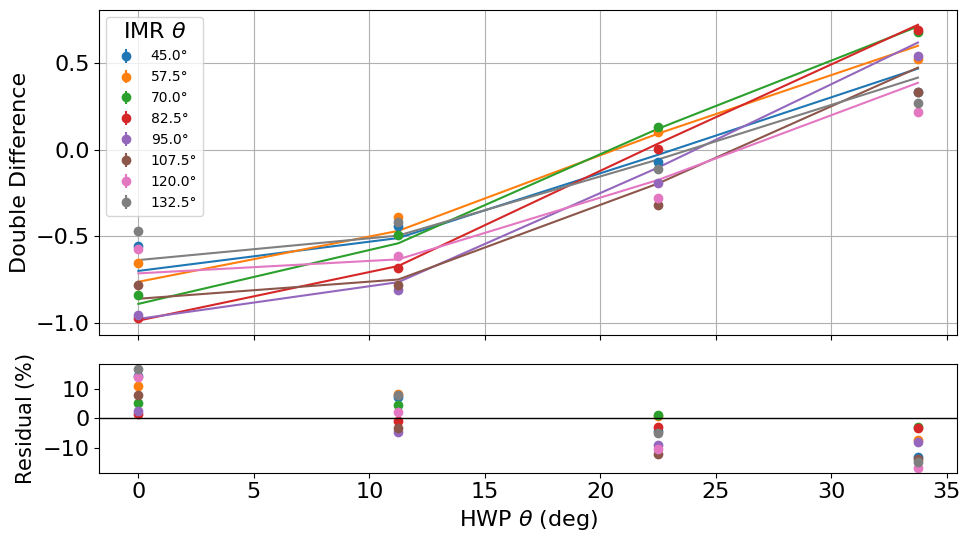

[-0.70063944 -0.51065104 -0.0291438   0.46914603 -0.76358001 -0.46917785
  0.0931829   0.60069684 -0.89121724 -0.54091736  0.12138833  0.71240177
 -0.98792196 -0.6721667   0.0354121   0.72217363 -0.978146   -0.76558434
 -0.10318318  0.61971339 -0.86162977 -0.75043296 -0.19523533  0.47449602
 -0.71493322 -0.63384137 -0.17483562  0.38683808 -0.63799868 -0.49642131
 -0.05645815  0.41686595]
[np.float64(3.0570640046313304), np.float64(0.8357196966340271)] [['hwp', 'phi'], ['image_rotator', 'phi_h']]


In [4]:

# Get our model retardances from Joost t Hart physical models

p = [HWP_retardance(wavelength_bins,1.66725,1.30159)[15], IMR_retardance(wavelength_bins,259.14673)[15]]


# Define what is in the p list

system_parameters = [['hwp', 'phi'], ['image_rotator', 'phi_h']]

# Generate our modeled left and right beam intensities

modeled_interleaved = model(p, system_parameters, system_mm, configuration_list)

# Process these into interleaved single norm differences and sums

diffs_sums = process_model(modeled_interleaved)

# Plot the modeled and observed values

fig, ax = plot_data_and_model(interleaved_values, diffs_sums,configuration_list, wavelength= wavelength_bins[15],include_sums=False,title='')
ax.tick_params(
    axis='x',
    direction='in',
    top=True,
    which='both',  
)
ax.tick_params(
    axis='y',
    direction='in',
    right=True,
    which='both',
)
ax.minorticks_on()
#fig.savefig('/Users/thomasmcintosh/Desktop/CHARIS-REU/overleaf_plots/MCMC_model_single_diff_vs_hwp_1932.png',bbox_inches='tight', dpi=600)
diffs = process_dataset(interleaved_values)[::2]
print(diffs_sums[::2])
pol_acc = np.sqrt(np.sum((diffs*100-diffs_sums[::2]*100)**2)/(len(diffs)-6))
pol_acc
print(p, system_parameters)

# Step 3: Fit for Retardances

ABOUT THE FITTING FUNCTION/HOW I USE IT: I made a function that does everything quickly but is also tailored to the parameters I am fitting. My function fits using scipy least squares, updates the model, puts the pyMuellerMat compatible system dictionary in a JSON file, and optionally saves a plot of the model vs data to a specified path.
If you want to use it for different parameters than the ones in the p0 dictionary within the function, 
you'll have to update the function a bit (which shouldn't take too long). This is a wrapper function for the main minimization function in fitting.py. I've found it easier to use this function and tailor the parameters that it's fitting to what I need instead of using that fitting function. The things you need to edit in this function in instruments.py to fit new parameters are marked with all caps comments that look like this: # IF YOU WANT TO MODIFY YOUR PARAMETERS, EDIT THIS

This funciton calculates s_res, which is a metric used in previous polcal papers to quantify goodness of fit. It's essentially a corrected average of residuals. It also calculates error on fit from a Jacobian estimation technique from Rob Van Holstein's 2020 VLT SPHERE polcal paper.

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.7334e-01                                    8.00e+00    
       1              2         1.1462e-03      1.72e-01       2.18e-01       6.53e-01    
       2              3         8.2868e-05      1.06e-03       1.37e-02       5.26e-04    
       3              4         3.9718e-05      4.32e-05       3.67e-03       5.34e-05    
       4              5         3.7728e-05      1.99e-06       8.14e-04       3.48e-06    
       5              6         3.7718e-05      9.83e-09       6.10e-05       1.97e-08    
       6              7         3.7718e-05      3.14e-13       3.47e-07       6.58e-11    
`gtol` termination condition is satisfied.
Function evaluations 7, initial cost 1.7334e-01, final cost 3.7718e-05, first-order optimality 6.58e-11.
     message: `gtol` termination condition is satisfied.
     success: True
      status: 1
         fun: [-1.690e-04  2.250

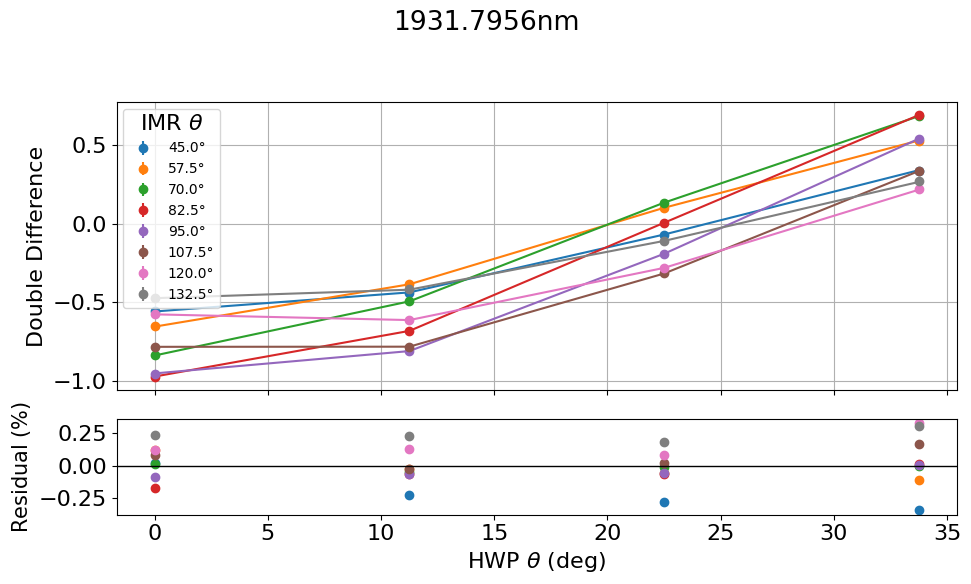

Updated Mueller Matrix:
[[ 0.66037146 -0.66037146  0.          0.        ]
 [-0.65727202  0.65727202  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.34564791156081043 0.3280429886480576
s_res: 0.16715147084006365
Error: [0.00077789 0.00050938 0.00105504 0.00175037 0.00062228]


/tmp/ipykernel_246491/3250571384.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


In [5]:
# Test fitting with the wavelength bin we plotted earlier
from pyPolCal.instruments import fit_CHARIS_Mueller_matrix_by_bin
error, fig2, ax2,sres = fit_CHARIS_Mueller_matrix_by_bin(filepath, 15, 
    Path('/home/thomasmc/nbs_in/pol/sys_dicts/test.json'),
    )
ax2.tick_params(
    axis='x',
    direction='in',
    top=True,
    which='both',  
)
ax2.tick_params(
    axis='y',
    direction='in',
    right=True,
    which='both',
)
ax2.minorticks_on()
fig2.suptitle('')
fig2.show()
#fig2.savefig('/Users/thomasmcintosh/Desktop/CHARIS-REU/overleaf_plots/naive_model_single_diff_vs_hwp_1932.png',bbox_inches='tight', dpi=600)



The elliptical IMR model is a huge improvement! Now we can fit for all bins. In this fit, I'm fitting for 3 elliptical retarder parameters and a Wollaston prism modulator term.

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.1205e-01                                    4.96e+00    
       1              2         4.7870e-03      1.07e-01       2.85e-01       6.04e-01    
       2              3         2.9055e-03      1.88e-03       2.82e-02       7.84e-03    
       3              4         2.9007e-03      4.79e-06       3.12e-03       9.93e-05    
       4              5         2.9007e-03      4.21e-10       2.24e-05       1.91e-06    
       5              6         2.9007e-03      1.34e-13       5.29e-07       3.76e-08    
`ftol` termination condition is satisfied.
Function evaluations 6, initial cost 1.1205e-01, final cost 2.9007e-03, first-order optimality 3.76e-08.
     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [-1.781e-03  1.321e-03 ...  2.534e-02  1.265e-02]
           x: [ 4.301e+00  4.421e-26  2.235e-01  2.985e+00 

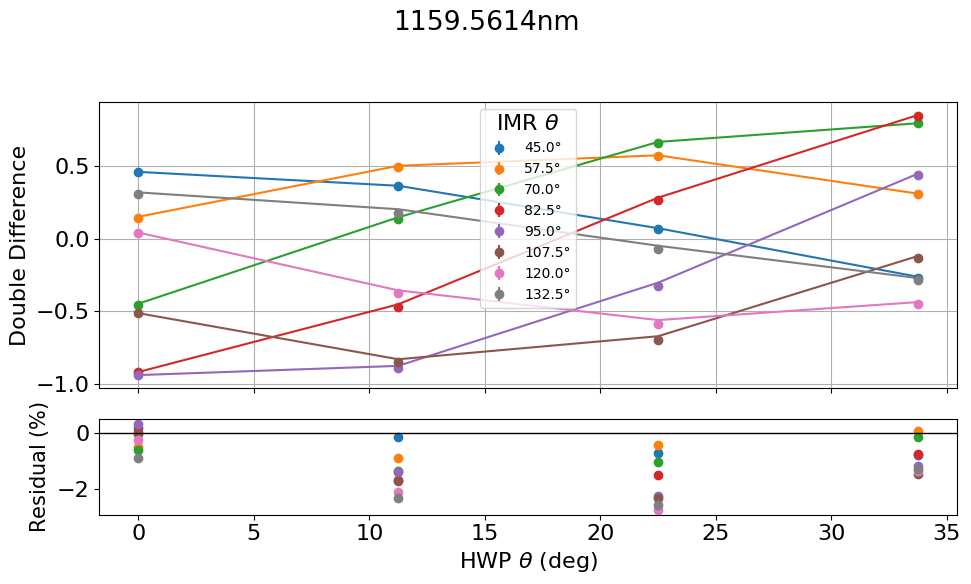

Updated Mueller Matrix:
[[ 0.31599186 -0.31599186  0.          0.        ]
 [-0.31599186  0.31599186  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -2.739403438679304 0.3200707313463482
s_res: 1.4658403347113536
Error: [0.0059589  0.01739542 0.01320665 0.0140134  0.00552825]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.3524e-01                                    4.04e+00    
       1              2         4.9844e-03      1.30e-01       2.93e-01       5.99e-01    
       2              3         2.3752e-03      2.61e-03       3.60e-02       7.26e-02    
       3              4         1.9693e-03      4.06e-04       1.45e-02       2.75e-03    
       4              5         1.9692e-03      8.91e-08       2.67e-04       1.07e-06    
       5              6         1.9692e-03      1.71e-14       1.59e-07  

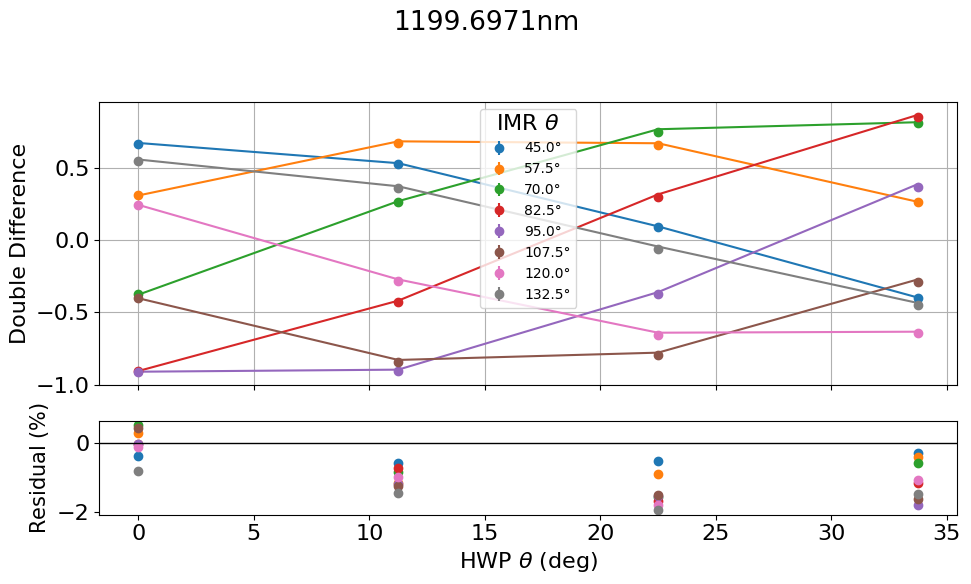

Updated Mueller Matrix:
[[ 0.24137699 -0.24137699  0.          0.        ]
 [-0.23322496  0.23322496  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.9525648319088695 0.5221234046844501
s_res: 1.2077419663375826
Error: [0.00652176 0.01601739 0.00881856 0.0138175  0.00457308]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.5405e-02                                    4.16e+00    
       1              2         2.2263e-03      8.32e-02       2.24e-01       2.55e-01    
       2              3         1.5160e-03      7.10e-04       2.45e-02       4.90e-02    
       3              4         1.3333e-03      1.83e-04       1.20e-02       1.54e-03    
       4              5         1.3333e-03      3.42e-08       1.99e-04       1.10e-06    
       5              6         1.3333e-03      1.15e-13       3.15e-07 

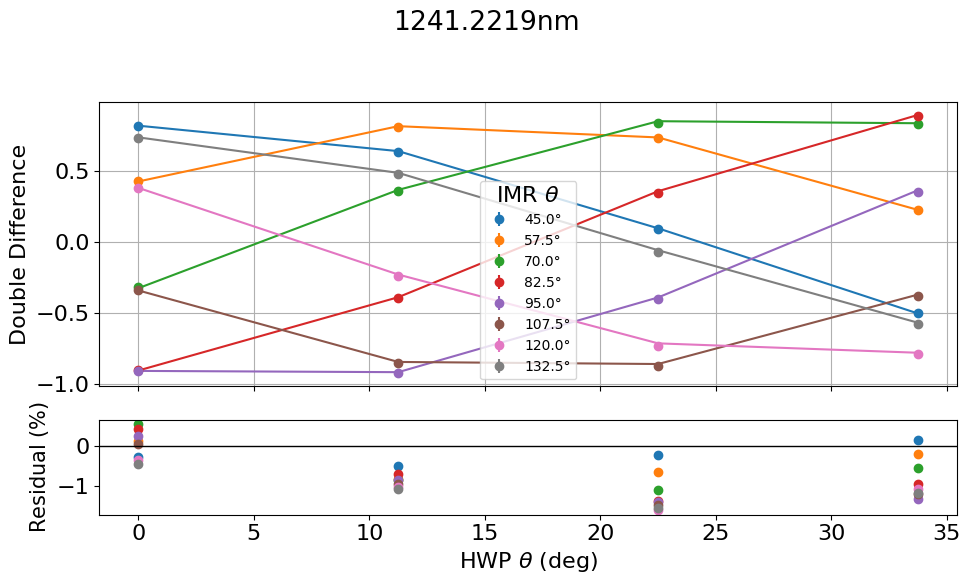

Updated Mueller Matrix:
[[ 0.18612565 -0.18612565  0.          0.        ]
 [-0.18024393  0.18024393  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.6104602262868326 0.5426493726190316
s_res: 0.9938010925791059
Error: [0.0073662  0.0156626  0.00620957 0.01437542 0.00377903]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.4410e-02                                    5.43e+00    
       1              2         1.3872e-03      8.30e-02       1.91e-01       1.59e-01    
       2              3         4.9982e-04      8.87e-04       3.71e-02       4.99e-04    
       3              4         3.5654e-04      1.43e-04       1.36e-02       5.17e-04    
       4              5         3.3444e-04      2.21e-05       2.64e-03       1.15e-04    
       5              6         3.3368e-04      7.57e-07       1.38e-04 

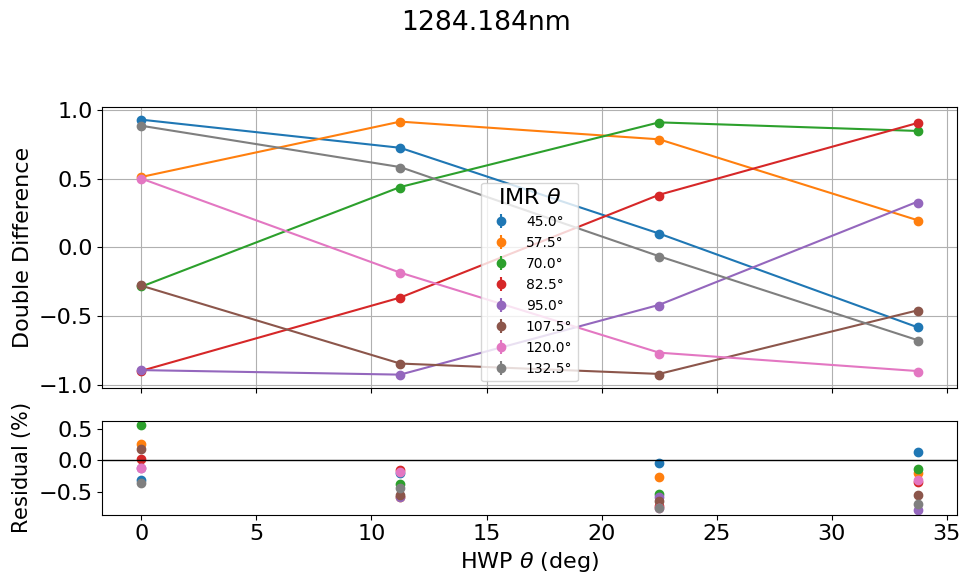

Updated Mueller Matrix:
[[ 0.14584928 -0.14584928  0.          0.        ]
 [-0.13307854  0.13307854  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.8008933975004737 0.5651029781257257
s_res: 0.4971613084866859
Error: [0.00659334 0.01193733 0.00271476 0.01196842 0.00193169]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.7158e-02                                    6.28e+00    
       1              2         1.3055e-03      8.59e-02       2.27e-01       2.77e-01    
       2              3         1.8948e-04      1.12e-03       6.71e-02       3.90e-03    
       3              4         6.3410e-05      1.26e-04       3.52e-02       2.34e-03    
       4              5         5.0318e-05      1.31e-05       1.20e-02       4.75e-04    
       5              6         4.9707e-05      6.11e-07       1.96e-03 

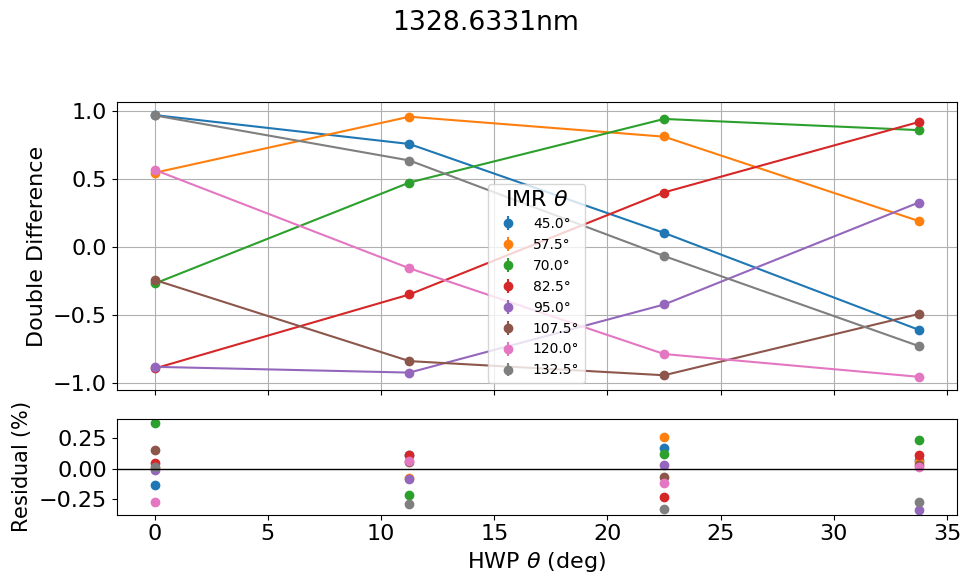

Updated Mueller Matrix:
[[ 0.13233052 -0.13233052  0.          0.        ]
 [-0.11706798  0.11706798  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.3431957089864497 0.37237479922804795
s_res: 0.19176545633489195
Error: [0.00613403 0.0101631  0.00099441 0.01077602 0.00072524]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.3245e-02                                    6.27e+00    
       1              2         5.1102e-04      8.27e-02       1.85e-01       8.33e-02    
       2              3         1.1779e-04      3.93e-04       2.24e-02       1.52e-03    
       3              4         9.4291e-05      2.35e-05       6.69e-03       1.94e-04    
       4              5         9.3781e-05      5.09e-07       1.08e-03       4.57e-06    
       5              6         9.3781e-05      4.73e-10       3.98e-0

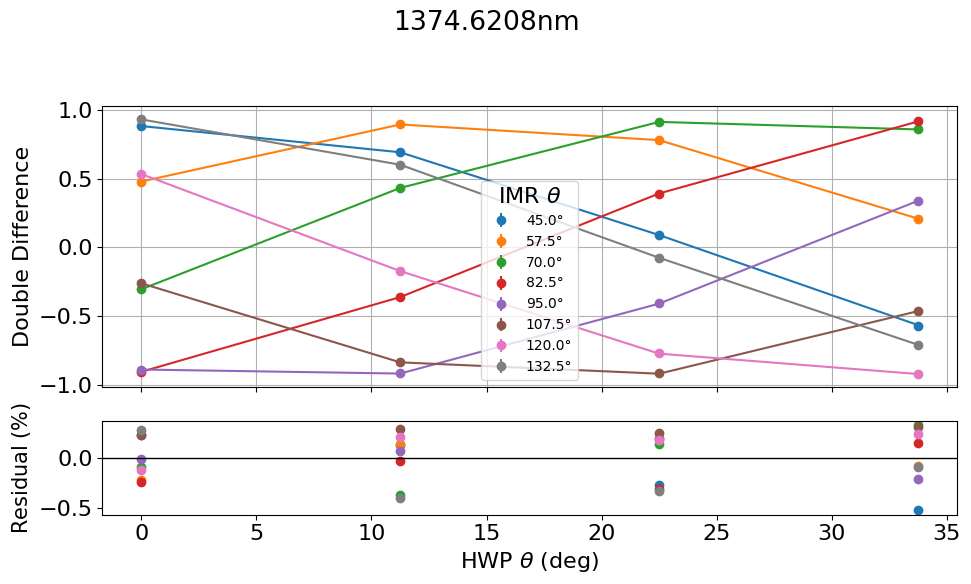

Updated Mueller Matrix:
[[ 0.16060737 -0.16060737  0.          0.        ]
 [-0.1486719   0.1486719   0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.5271548935772614 0.3249673148551153
s_res: 0.263566632074138
Error: [0.00345231 0.0048877  0.00112735 0.00625806 0.00102051]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.0035e-02                                    6.00e+00    
       1              2         5.4757e-04      6.95e-02       1.31e-01       1.79e-01    
       2              3         2.1855e-04      3.29e-04       2.29e-02       5.91e-04    
       3              4         2.1569e-04      2.86e-06       1.55e-03       2.19e-05    
       4              5         2.1568e-04      7.31e-09       7.61e-05       1.88e-07    
       5              6         2.1568e-04      6.84e-14       2.24e-07  

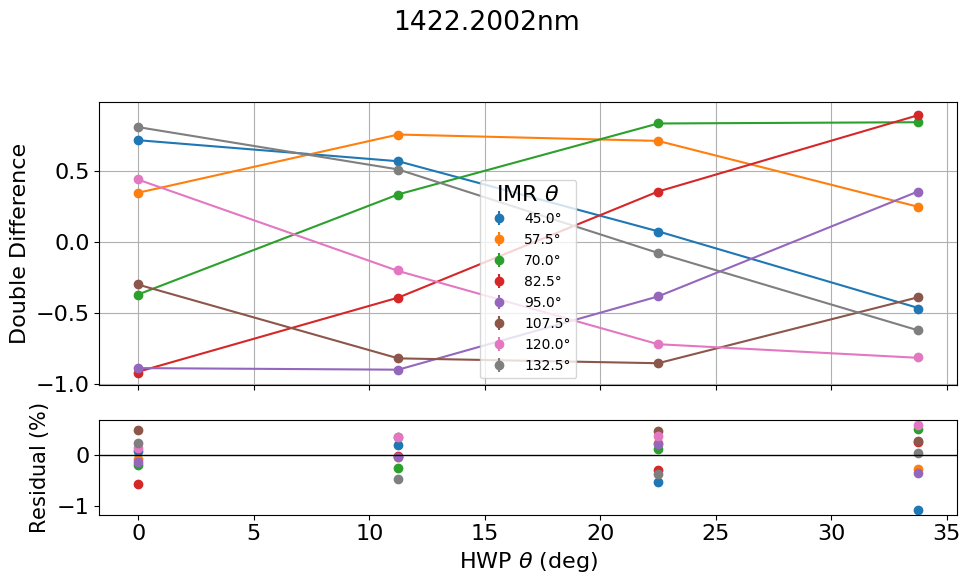

Updated Mueller Matrix:
[[ 0.21792215 -0.21792215  0.          0.        ]
 [-0.20592538  0.20592538  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.081333578452842 0.5873954516807771
s_res: 0.39970678404034377
Error: [0.00296506 0.00411548 0.00164492 0.00579909 0.00151532]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.6262e-02                                    5.04e+00    
       1              2         4.3996e-04      4.58e-02       1.09e-01       1.62e-01    
       2              3         3.5097e-04      8.90e-05       5.88e-03       2.33e-04    
       3              4         3.4964e-04      1.33e-06       7.46e-04       6.69e-06    
       4              5         3.4963e-04      2.12e-09       3.07e-05       9.94e-08    
       5              6         3.4963e-04      6.33e-15       5.19e-08 

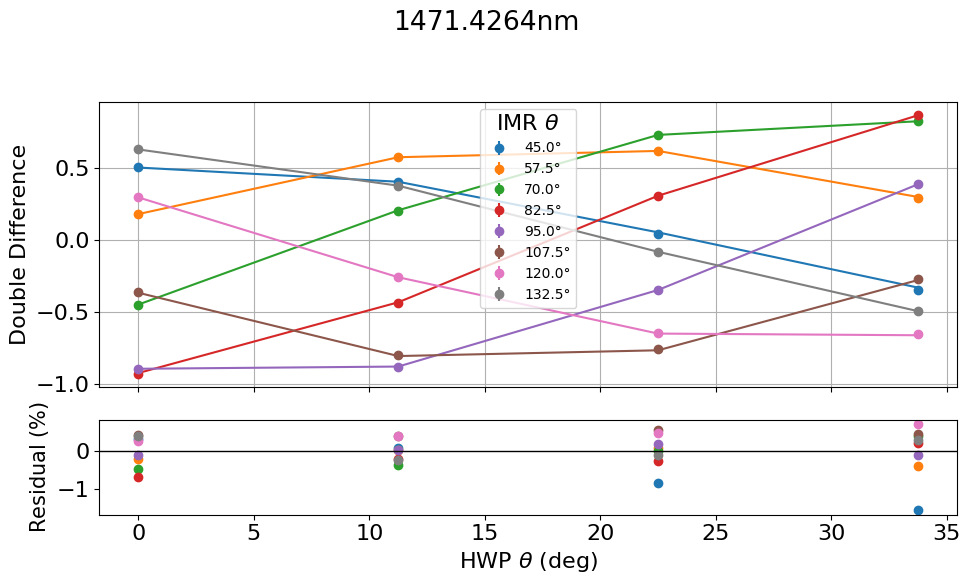

Updated Mueller Matrix:
[[ 0.29259626 -0.29259626  0.          0.        ]
 [-0.28242904  0.28242904  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.5845442379436392 0.7204385494514582
s_res: 0.5089083693973375
Error: [0.00257933 0.00354367 0.00208747 0.00561188 0.00191273]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.1728e-02                                    3.88e+00    
       1              2         4.3263e-04      3.13e-02       1.00e-01       1.06e-01    
       2              3         3.6820e-04      6.44e-05       4.69e-03       1.01e-04    
       3              4         3.6734e-04      8.59e-07       5.23e-04       2.84e-06    
       4              5         3.6734e-04      7.60e-10       1.59e-05       4.77e-08    
       5              6         3.6734e-04      6.85e-16       1.49e-08 

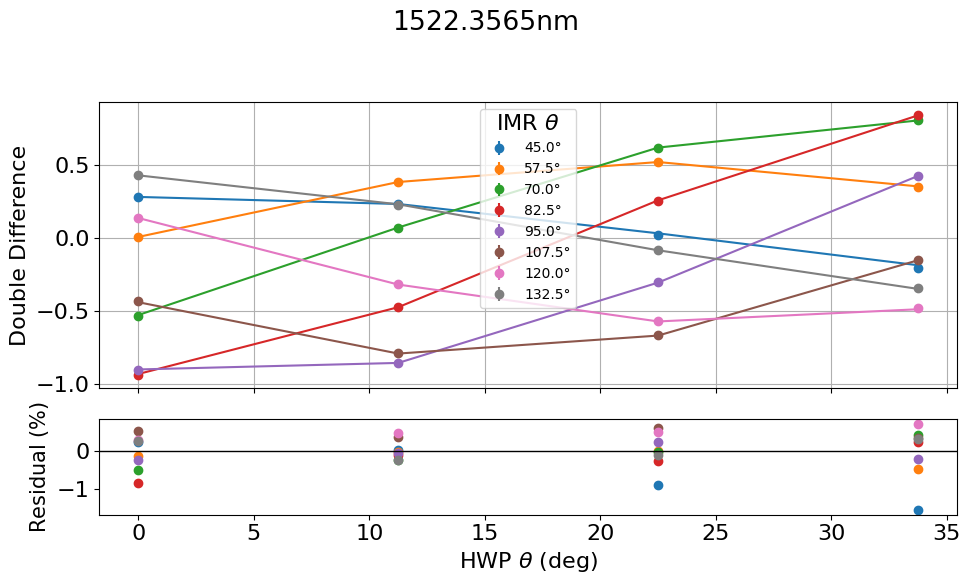

Updated Mueller Matrix:
[[ 0.37177912 -0.37177912  0.          0.        ]
 [-0.36197151  0.36197151  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.5723631528567346 0.7308112969368707
s_res: 0.5216335618621204
Error: [0.00208892 0.00280732 0.0022036  0.00501762 0.00195522]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         4.0855e-02                                    3.09e+00    
       1              2         3.8883e-04      4.05e-02       1.13e-01       1.39e-01    
       2              3         2.8747e-04      1.01e-04       5.59e-03       8.67e-05    
       3              4         2.8577e-04      1.70e-06       6.79e-04       3.08e-06    
       4              5         2.8577e-04      3.77e-09       3.32e-05       7.59e-08    
       5              6         2.8577e-04      2.25e-14       8.12e-08 

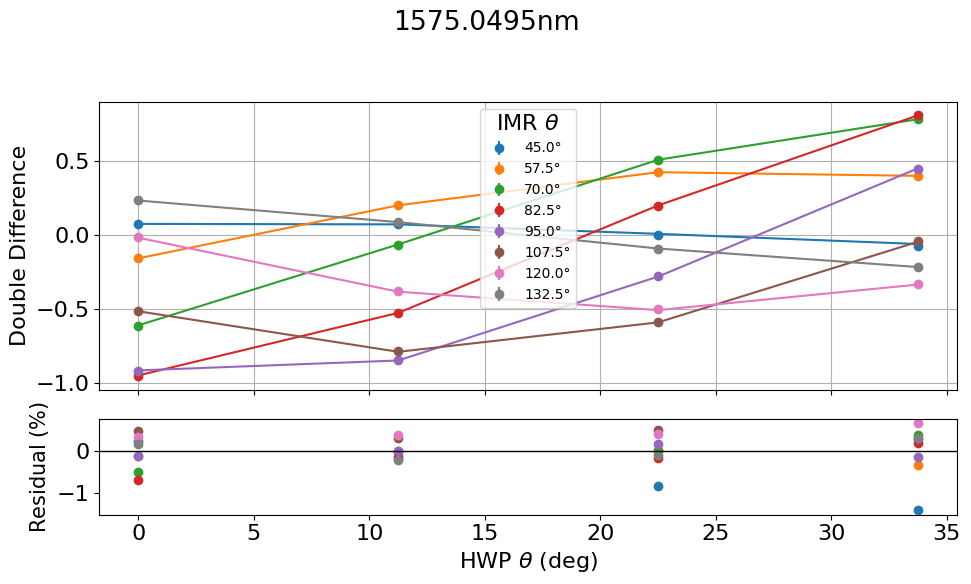

Updated Mueller Matrix:
[[ 0.44301282 -0.44301282  0.          0.        ]
 [-0.43562548  0.43562548  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.4223895563291107 0.666932865675534
s_res: 0.46008617678641656
Error: [0.00163385 0.00207558 0.00203252 0.00416754 0.00172139]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.6540e-02                                    3.40e+00    
       1              2         5.2299e-04      5.60e-02       1.24e-01       2.40e-01    
       2              3         3.5441e-04      1.69e-04       6.67e-03       1.53e-04    
       3              4         3.5244e-04      1.96e-06       7.16e-04       3.76e-06    
       4              5         3.5244e-04      4.38e-09       3.52e-05       1.05e-07    
       5              6         3.5244e-04      2.62e-14       8.63e-08 

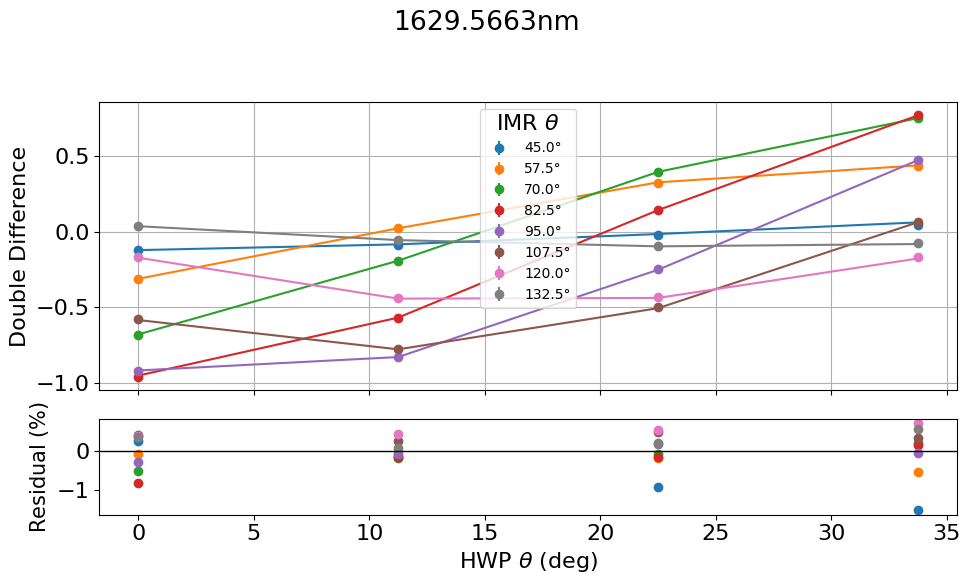

Updated Mueller Matrix:
[[ 0.51126211 -0.51126211  0.          0.        ]
 [-0.50431481  0.50431481  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.5275157379833866 0.7151232983943601
s_res: 0.5109444736222798
Error: [0.00176938 0.00201351 0.00241634 0.00458222 0.0019094 ]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.8321e-02                                    4.63e+00    
       1              2         5.2960e-04      7.78e-02       1.38e-01       3.39e-01    
       2              3         2.7194e-04      2.58e-04       7.60e-03       1.88e-04    
       3              4         2.6882e-04      3.13e-06       9.11e-04       5.73e-06    
       4              5         2.6880e-04      1.29e-08       6.14e-05       1.71e-07    
       5              6         2.6880e-04      2.84e-13       2.89e-07 

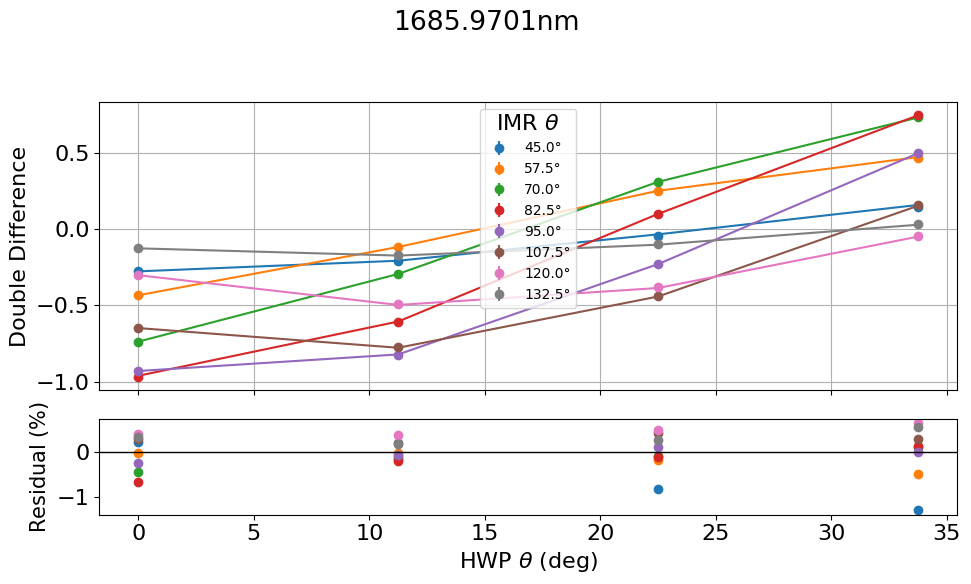

Updated Mueller Matrix:
[[ 0.56466228 -0.56466228  0.          0.        ]
 [-0.55914548  0.55914548  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -1.2986858823140608 0.636513423542711
s_res: 0.4462216418938441
Error: [0.00161165 0.00159898 0.0022658  0.00408134 0.00166595]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.1193e-01                                    5.72e+00    
       1              2         5.4693e-04      1.11e-01       1.63e-01       4.50e-01    
       2              3         1.2530e-04      4.22e-04       9.14e-03       2.29e-04    
       3              4         1.1705e-04      8.24e-06       1.49e-03       1.30e-05    
       4              5         1.1694e-04      1.08e-07       1.80e-04       3.24e-07    
       5              6         1.1694e-04      2.91e-11       3.01e-06  

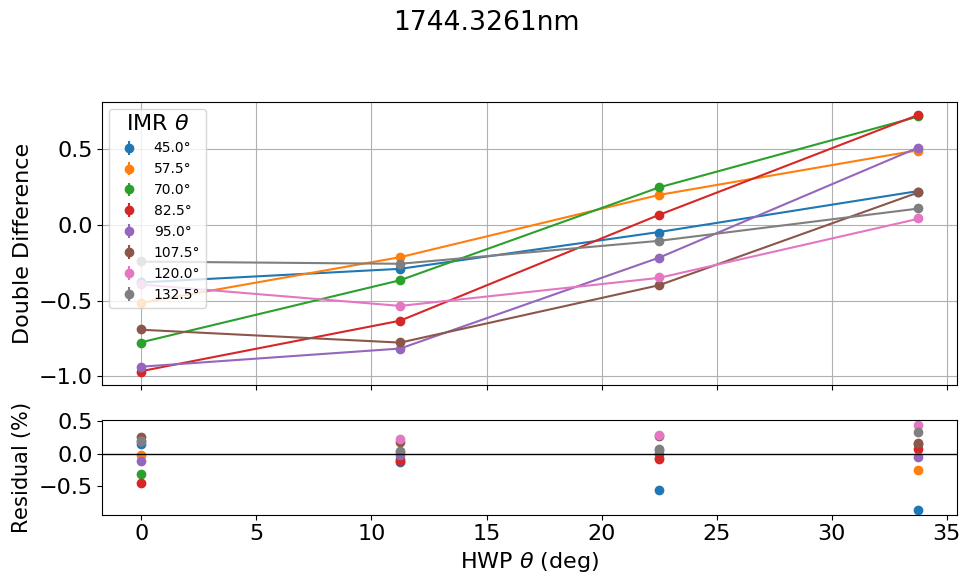

Updated Mueller Matrix:
[[ 0.60020031 -0.60020031  0.          0.        ]
 [-0.5961213   0.5961213   0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.8855425787495115 0.44832556566115045
s_res: 0.2943213726956506
Error: [0.00112992 0.00099212 0.00158731 0.00277203 0.00109777]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.4152e-01                                    6.80e+00    
       1              2         7.8360e-04      1.41e-01       1.85e-01       5.55e-01    
       2              3         1.4258e-04      6.41e-04       1.08e-02       2.79e-04    
       3              4         1.2626e-04      1.63e-05       2.17e-03       2.38e-05    
       4              5         1.2592e-04      3.43e-07       3.30e-04       6.71e-07    
       5              6         1.2592e-04      2.72e-10       9.54e-06

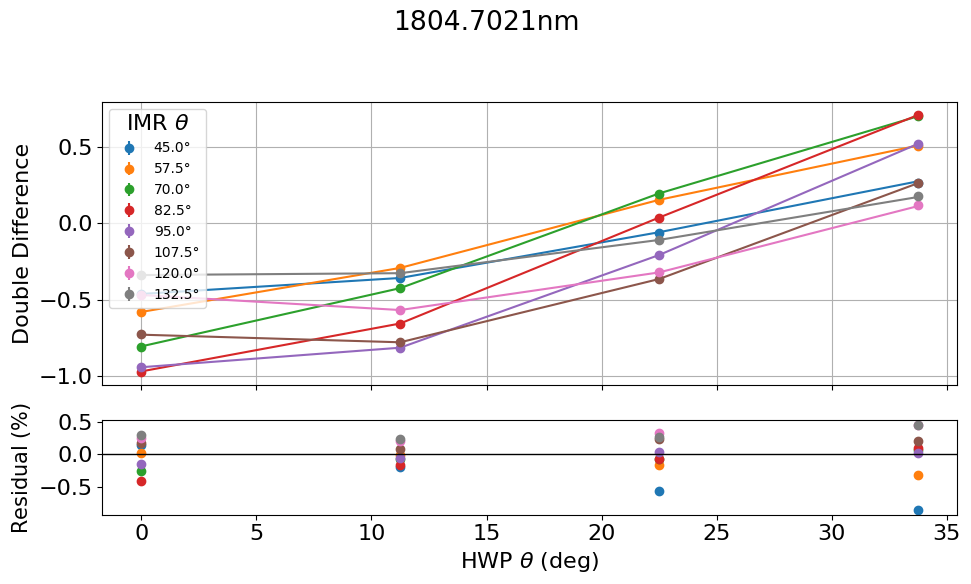

Updated Mueller Matrix:
[[ 0.62777558 -0.62777558  0.          0.        ]
 [-0.62393254  0.62393254  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.8615171001819419 0.4528048069768005
s_res: 0.3054095848783249
Error: [0.00126069 0.00098469 0.00175184 0.00298996 0.00113811]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.5394e-01                                    7.53e+00    
       1              2         9.3342e-04      1.53e-01       1.98e-01       5.98e-01    
       2              3         1.2543e-04      8.08e-04       1.18e-02       3.48e-04    
       3              4         9.6086e-05      2.93e-05       2.92e-03       3.84e-05    
       4              5         9.4959e-05      1.13e-06       6.04e-04       2.03e-06    
       5              6         9.4956e-05      3.53e-09       3.56e-05 

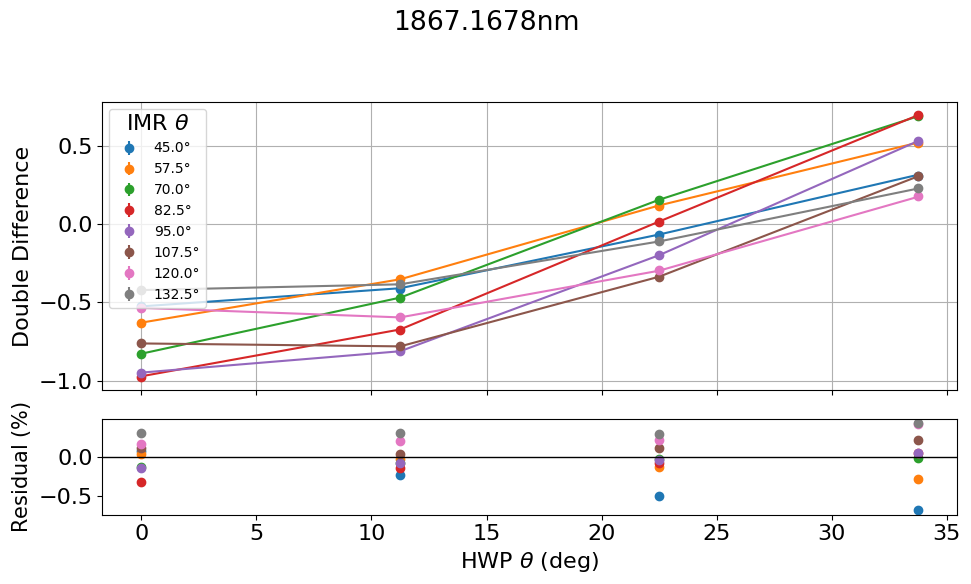

Updated Mueller Matrix:
[[ 0.64912605 -0.64912605  0.          0.        ]
 [-0.64600872  0.64600872  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.6853925405416739 0.43675558702346606
s_res: 0.2652124744230463
Error: [0.00117442 0.00082481 0.00160934 0.0026986  0.00098766]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.7334e-01                                    8.00e+00    
       1              2         1.1462e-03      1.72e-01       2.18e-01       6.53e-01    
       2              3         8.2868e-05      1.06e-03       1.37e-02       5.26e-04    
       3              4         3.9718e-05      4.32e-05       3.67e-03       5.34e-05    
       4              5         3.7728e-05      1.99e-06       8.14e-04       3.48e-06    
       5              6         3.7718e-05      9.83e-09       6.10e-05

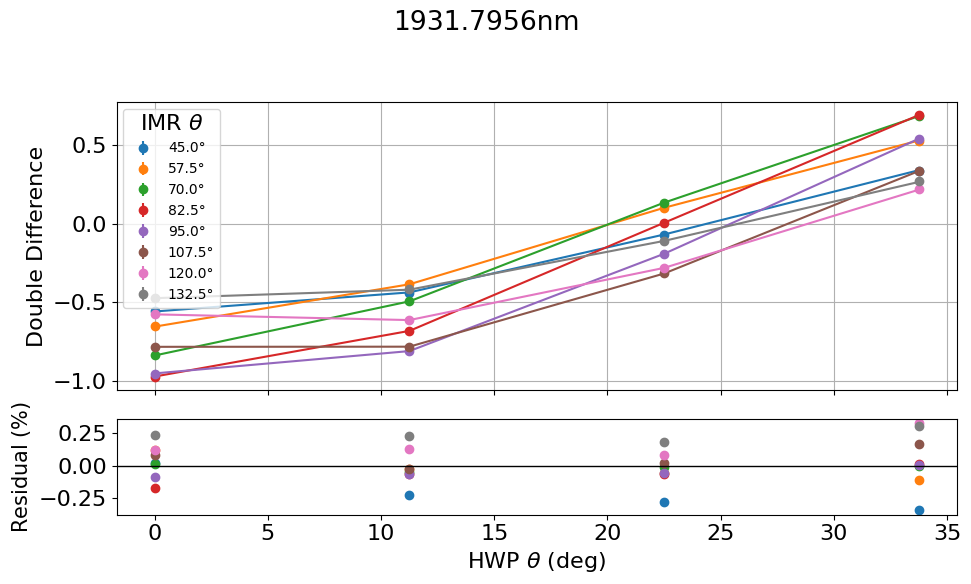

Updated Mueller Matrix:
[[ 0.66037146 -0.66037146  0.          0.        ]
 [-0.65727202  0.65727202  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.34564791156081043 0.3280429886480576
s_res: 0.16715147084006365
Error: [0.00077789 0.00050938 0.00105504 0.00175037 0.00062228]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.9883e-01                                    8.47e+00    
       1              2         1.6499e-03      1.97e-01       2.43e-01       7.10e-01    
       2              3         1.1348e-04      1.54e-03       1.69e-02       9.73e-04    
       3              4         2.7830e-05      8.57e-05       4.93e-03       8.73e-05    
       4              5         1.9788e-05      8.04e-06       1.52e-03       1.17e-05    
       5              6         1.9577e-05      2.11e-07       2.79e-0

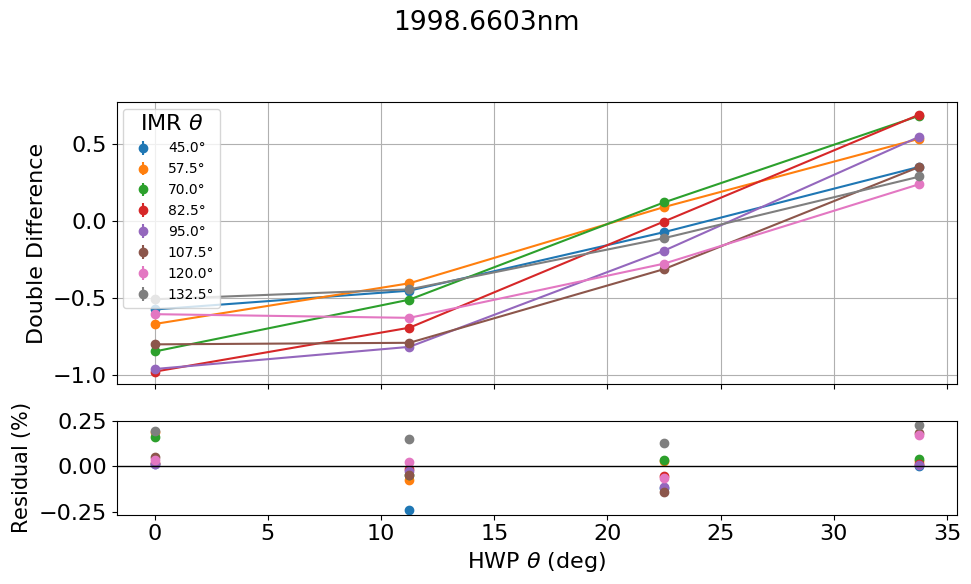

Updated Mueller Matrix:
[[ 0.66422154 -0.66422154  0.          0.        ]
 [-0.66205919  0.66205919  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.24282777288213708 0.2301877470899747
s_res: 0.12042108691883326
Error: [0.00057378 0.00036214 0.00077382 0.00127656 0.00044833]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.1598e-01                                    8.73e+00    
       1              2         1.9781e-03      2.14e-01       2.58e-01       7.71e-01    
       2              3         1.1672e-04      1.86e-03       1.89e-02       1.18e-03    
       3              4         3.2296e-05      8.44e-05       5.44e-03       9.60e-05    
       4              5         2.7677e-05      4.62e-06       1.26e-03       7.80e-06    
       5              6         2.7640e-05      3.71e-08       1.22e-0

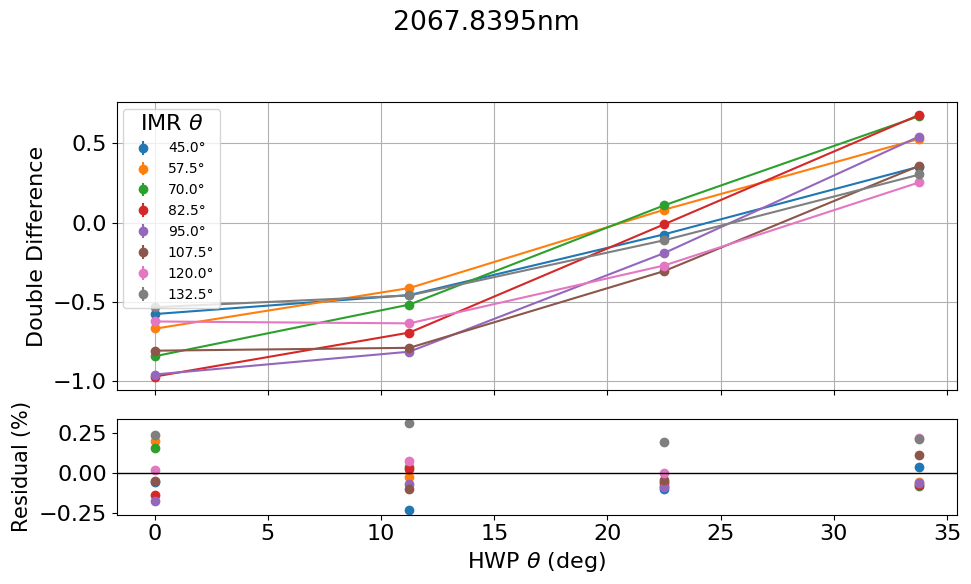

Updated Mueller Matrix:
[[ 0.66481785 -0.66481785  0.          0.        ]
 [-0.66131162  0.66131162  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.23372029539488892 0.3149821015718217
s_res: 0.143087676206977
Error: [0.00069894 0.00042857 0.00093837 0.00154047 0.00053305]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.2761e-01                                    8.71e+00    
       1              2         2.3406e-03      2.25e-01       2.72e-01       7.83e-01    
       2              3         1.5059e-04      2.19e-03       2.09e-02       1.50e-03    
       3              4         4.0957e-05      1.10e-04       6.16e-03       1.17e-04    
       4              5         3.3818e-05      7.14e-06       1.53e-03       1.15e-05    
       5              6         3.3729e-05      8.86e-08       1.89e-04 

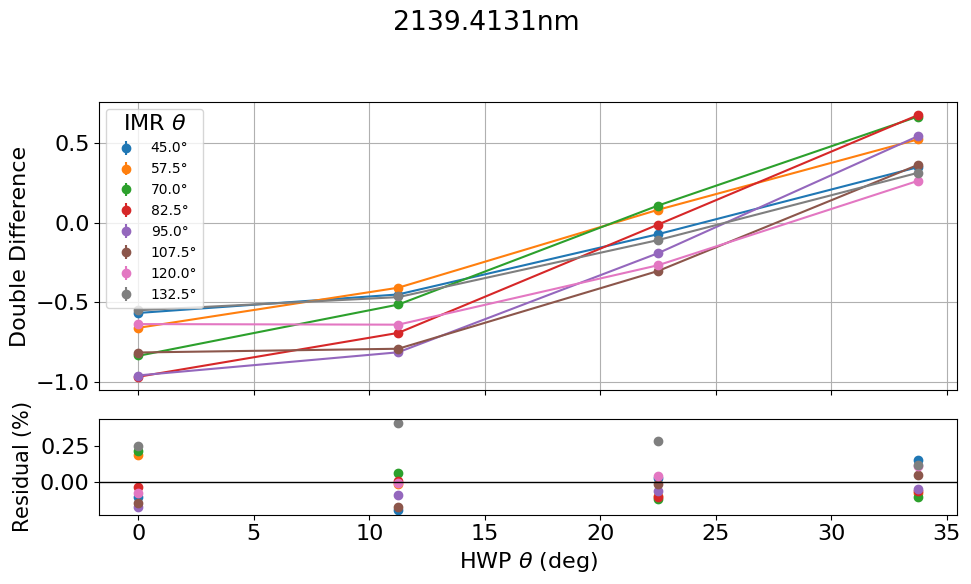

Updated Mueller Matrix:
[[ 0.66184157 -0.66184157  0.          0.        ]
 [-0.65847092  0.65847092  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.20305578784962108 0.41236483328842155
s_res: 0.15806471213874213
Error: [0.00077519 0.00047202 0.00103963 0.00170257 0.00058966]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.4873e-01                                    8.45e+00    
       1              2         2.5923e-03      2.46e-01       2.87e-01       8.20e-01    
       2              3         1.5486e-04      2.44e-03       2.25e-02       1.56e-03    
       3              4         5.6982e-05      9.79e-05       6.45e-03       1.11e-04    
       4              5         5.3747e-05      3.24e-06       1.09e-03       5.81e-06    
       5              6         5.3737e-05      9.86e-09       6.39e-

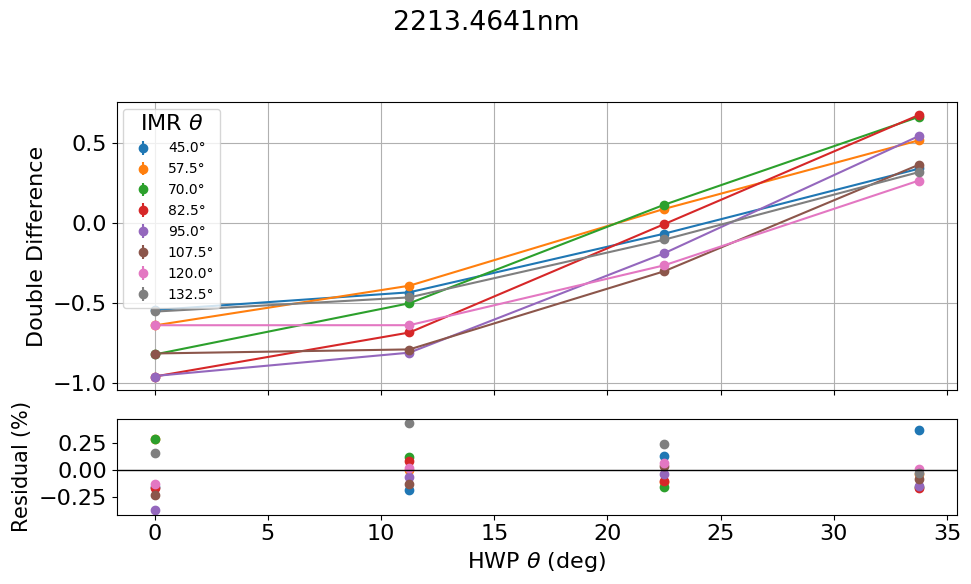

Updated Mueller Matrix:
[[ 0.65468245 -0.65468245  0.          0.        ]
 [-0.64943441  0.64943441  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.37774576177027086 0.42941582808588663
s_res: 0.19951206497972562
Error: [0.00097474 0.00060051 0.00130966 0.00214479 0.00074574]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.5627e-01                                    8.19e+00    
       1              2         2.5734e-03      2.54e-01       2.91e-01       8.26e-01    
       2              3         1.8399e-04      2.39e-03       2.23e-02       1.26e-03    
       3              4         9.8770e-05      8.52e-05       6.27e-03       9.79e-05    
       4              5         9.7009e-05      1.76e-06       8.18e-04       3.27e-06    
       5              6         9.7006e-05      2.08e-09       2.96e-

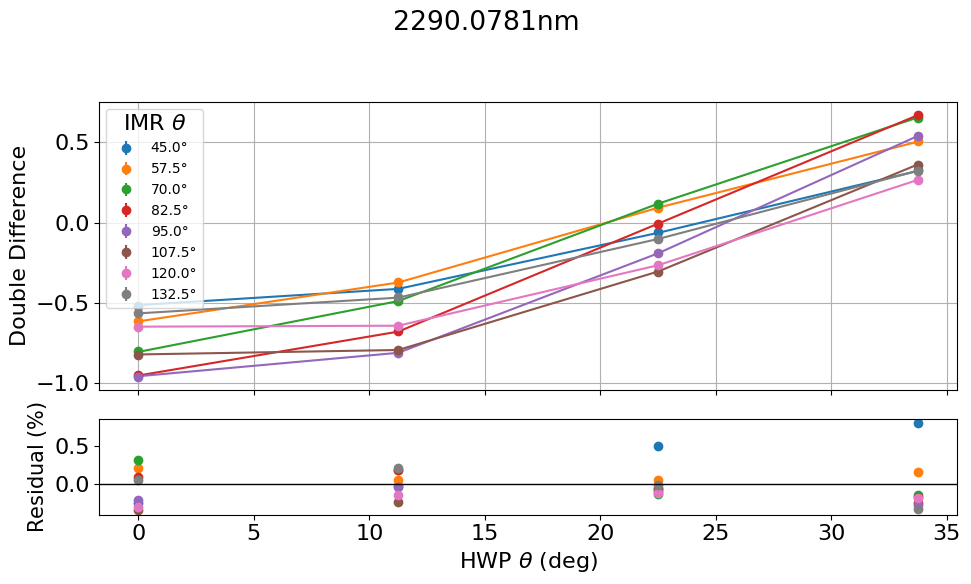

Updated Mueller Matrix:
[[ 0.64454054 -0.64454054  0.          0.        ]
 [-0.63789727  0.63789727  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.3403921995731025 0.7994532513419657
s_res: 0.26806092383321883
Error: [0.00130096 0.00081317 0.00175182 0.00286842 0.0010061 ]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.9352e-01                                    7.78e+00    
       1              2         2.6828e-03      2.91e-01       3.09e-01       8.83e-01    
       2              3         1.9349e-04      2.49e-03       2.37e-02       1.06e-03    
       3              4         1.3215e-04      6.13e-05       6.37e-03       5.86e-05    
       4              5         1.3182e-04      3.30e-07       4.32e-04       4.82e-07    
       5              6         1.3182e-04      1.76e-11       2.65e-06

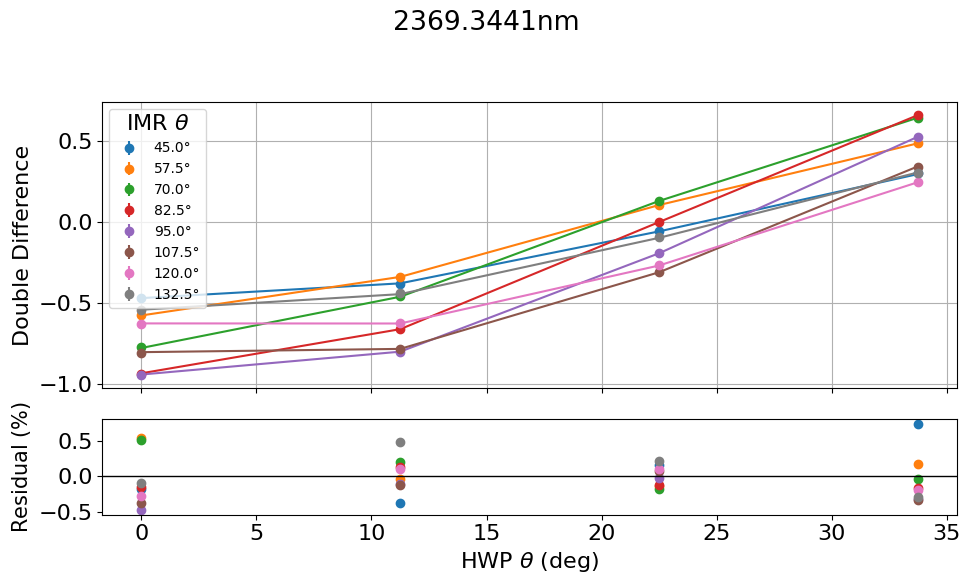

Updated Mueller Matrix:
[[ 0.63094594 -0.63094594  0.          0.        ]
 [-0.61974351  0.61974351  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]
128 64
Residuals range: -0.4807192125211657 0.7450863132734185
s_res: 0.31247953999577505
Error: [0.00148579 0.00097119 0.00201478 0.00331561 0.00117559]


In [6]:
# Fit all 22 wavelength bins
from pyPolCal.instruments import fit_CHARIS_Mueller_matrix_by_bin
from pathlib import Path
errors = []
sres_list = []
for bin in range(0,22):
    error,fig,ax,sres = fit_CHARIS_Mueller_matrix_by_bin(
        f'../datacsvs/pre_nbs_internalcal_pol_pick_out/bin{bin}.csv',bin,
        Path(f'../fitted_p_dicts/internalcal_july2025_pickout/bin{bin}.json'),
    )
    errors.append(error)
    sres_list.append(sres)



In [7]:
# find average error
import numpy as np
errors = np.array(errors)
print('phi_h', np.mean(errors[:,0]))
print('phi_45',np.mean(errors[:,1]))
print('phi_r',np.mean(errors[:,2]))
print('wol_eta',np.mean(errors[:,3]))




    

phi_h 0.002673955265478552
phi_45 0.00450803028010446
phi_r 0.0027069809511760887
wol_eta 0.005614903400901532


`model_data` will list out all of your fits in a data frame.

In [12]:
from pyPolCal.csv_tools import model_data
json_dir = '../fitted_p_dicts/internalcal_july2025_pickout'
df = model_data(json_dir, offsets=False)

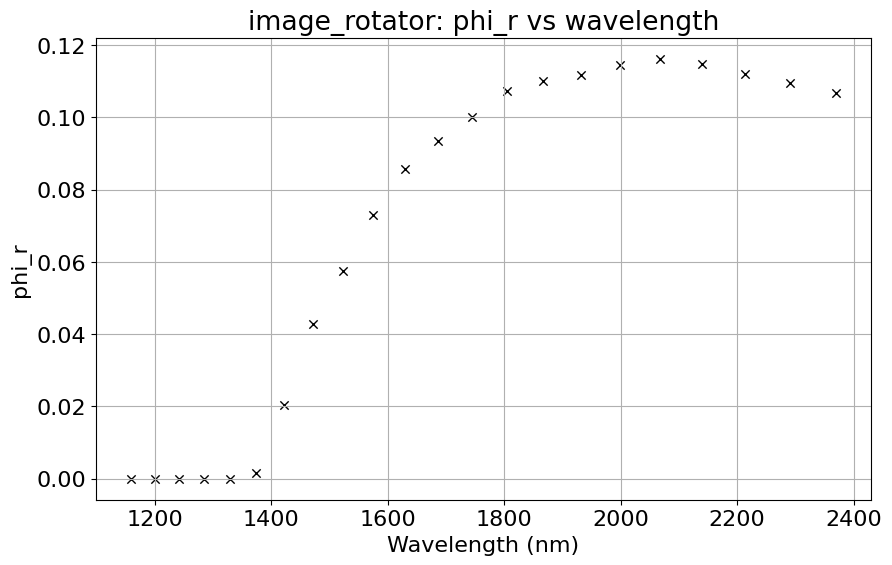

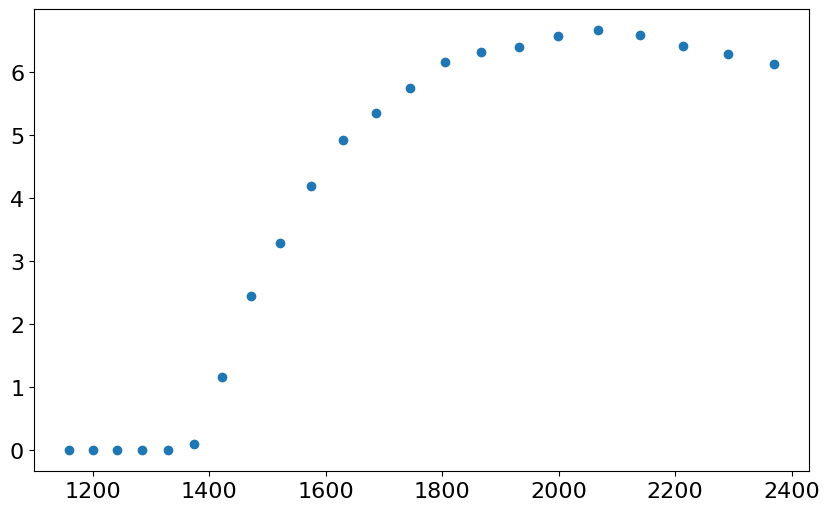

In [13]:
# plot 45 degree linear retardance
from pyPolCal.plotting import plot_config_dict_vs_wavelength
params, fig, ax = plot_config_dict_vs_wavelength('image_rotator', 'phi_r', json_dir)
fig, ax = plt.subplots(figsize=(10,6))
# plot in degrees
ax.scatter(wavelength_bins, np.rad2deg(params))

# Step 4: Fit for Global Parameters

In [17]:
# define custom mm functions
from pyPolCal.mm_registry import register_mm_function
from pyMuellerMat.common_mm_functions import elliptical_retarder_function

wavelength_fits_dir = '../fitted_p_dicts/internalcal_july2025_pickout' # path to fitted p dicts
wavelength_fits_df = model_data(wavelength_fits_dir) # saving to DataFrame
derotator_phi_h = wavelength_fits_df['image_rotator_phi_h'].to_numpy() # linear h retardance
derotator_phi_45 = wavelength_fits_df['image_rotator_phi_45'].to_numpy() # linear 45 retardance
derotator_phi_r = wavelength_fits_df['image_rotator_phi_r'].to_numpy() # circular retardance
wollaston_eta = wavelength_fits_df['wollaston_eta'].to_numpy()

@register_mm_function()
def fitted_derotator_function_july_2025(wavelength=500): # Only keyword arguments!
    phi_h = derotator_phi_h
    phi_45 = derotator_phi_45
    phi_r = derotator_phi_r

    # Interpolating retardance as a function of wavelength 
    phi_h_interp = np.interp(wavelength, wavelength_bins, phi_h)
    phi_45_interp = np.interp(wavelength, wavelength_bins, phi_45)
    phi_r_interp = np.interp(wavelength, wavelength_bins, phi_r)

    # using pyMuellerMat's elliptical retarder function
    return elliptical_retarder_function(phi_h_interp, phi_45_interp, phi_r_interp)

@register_mm_function()
def fitted_wollaston_function_july_2025(beam='o',wavelength=500): # Only keyword arguments!
    eta = wollaston_eta

    # Interpolating retardance as a function of wavelength
    eta_interp = np.interp(wavelength, wavelength_bins, eta)

    # using pyMuellerMat's elliptical retarder function
    return wollaston_prism_function(beam=beam,eta=eta_interp)

Mueller matrix function 'fitted_derotator_function_july_2025' is already registered. Overwriting.
Mueller matrix function 'fitted_wollaston_function_july_2025' is already registered. Overwriting.


In [18]:
# Get interleaved values for all wavelength bins
csvdir = Path('../datacsvs/pre_nbs_internalcal_pol_pick_out')

interleaved_values_all, interleaved_stds_all, configuration_list_all = read_csv_physical_model_all_bins(csvdir)

from pyPolCal.constants import wavelength_bins
wavelength_bin = 15 # placeholder
epsilon_cal = -1 # defining as perfect, reasoning in Joost t Hart 2021
offset_imr = -0.0018
offset_hwp = -0.0022 
offset_cal = -0.0315 
imr_theta = 0 # placeholder 
hwp_theta = 0 # placeholder
# Past fits from scipy minimize on the naive fits
d = 259.7
wsio2 = 1.613
wmgf2 = 1.261

# Define instrument configuration as system dictionary
# Wollaston beam, imr theta/phi, and hwp theta/phi will all be updated within functions, so don't worry about their values here

system_dict = {
"components" : {
    "wollaston" : {
        "type" : "fitted_wollaston_function_july_2025",
        "properties" : {"wavelength": wavelength_bins[wavelength_bin], "beam": 'o'}, 
        "tag": "internal",
    },

    "image_rotator" : {
        "type" : "fitted_derotator_function_july_2025",
        "properties" : {"wavelength":wavelength_bins[wavelength_bin], "theta": imr_theta, "delta_theta": offset_imr},
        "tag": "internal",
    },
    "hwp" : {
        "type" : "two_layer_HWP_function",
        "properties" : {"wavelength": wavelength_bins[wavelength_bin], "w_SiO2": wsio2, "w_MgF2": wmgf2, "theta":hwp_theta, "delta_theta": offset_hwp},
        "tag": "internal",
    },
    "lp" : {  # calibration polarizer for internal calibration source
        "type": "diattenuator_retarder_function",
        "properties": {"epsilon": epsilon_cal, "delta_theta": 0},
        "tag": "internal",
    }}
}
    
# Starting guesses

p0_dict = {
    "image_rotator" : 
        {"delta_theta": offset_imr},
    "hwp" :  
        {"w_SiO2": wsio2, "w_MgF2": wmgf2, "delta_theta": offset_hwp},
    "lp" : 
        {"delta_theta": offset_cal},
}

system_mm = generate_system_mueller_matrix(system_dict) # Generating pyMuellerMat system MM
print(system_mm.evaluate())
p0 = [1.623, 1.268, 262.56] # Starting guesses from Joost t Hart 2021 
offset_bounds = (-5,5) 
d_bounds = (0.8*p0[2], 1.2*p0[2]) # Physical parameters shouldn't have changed much
imr_offset_bounds = offset_bounds
wsio2_bounds = (0.6*p0[0], 1.4*p0[0])
wmgf2_bounds = (0.6*p0[1], 1.4*p0[1])
bounds=[offset_bounds,wsio2_bounds,wmgf2_bounds,offset_bounds,offset_bounds]
# Process everything into double differences and propagate errors





[[ 0.0079491  -0.0079491   0.          0.        ]
 [-0.00118578  0.00118578  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]


In [19]:
# Minimize everything globally with minimize
from pyPolCal.fitting import minimize_system_mueller_matrix
result_min, logl_min=minimize_system_mueller_matrix(p0_dict,system_mm,interleaved_values_all,
                               configuration_list_all,s_in=[1,0,0,0],process_dataset=process_dataset,
                               process_errors=process_errors, process_model=process_model,include_sums=False,
                               bounds=bounds,mode='minimize')
print(result_min)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.012474007824733471
        x: [-4.265e-02  1.642e+00  1.283e+00 -2.975e-02 -1.247e-02]
      nit: 34
      jac: [-9.501e-05 -2.646e-03  3.486e-03 -3.586e-04 -7.550e-04]
     nfev: 234
     njev: 39
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>


In [21]:
from pyPolCal.fitting import update_p0
update_p0(p0_dict,result_min.x)
s_rel = calc_s_res_global(csvdir, system_dict, p0_dict,number_of_fitted_params=5)


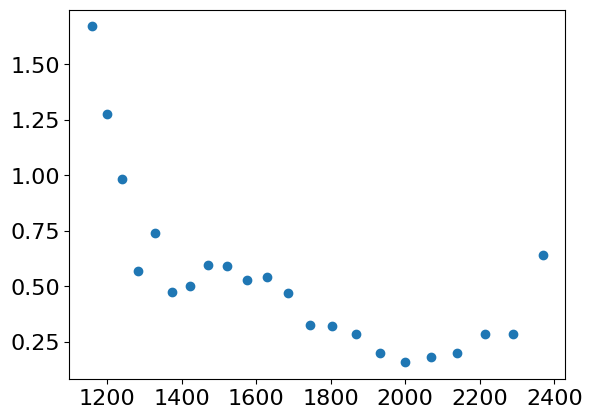

In [23]:
plt.scatter(wavelength_bins,s_rel)